# Six-terminal spin-resolved QH Hall-bar transport with Kwant

This notebook is the spin-resolved/exchange version of `qh_kwant_transport_six_terminal_hall_bar.ipynb`.
It is compatible with the output folders generated by
`sweeppone2_spin_exchange_verified.ipynb`.

The spin/exchange sweep saves, for each magnetic field:

```text
U_scalar, U_up, U_down, n_up, n_down, nu_up, nu_down, Vx_up, Vx_down, ...
```

For transport we use a robust decoupled-spin construction:

```text
H_up   = H_kin + U_up   + E_Z,up
H_down = H_kin + U_down + E_Z,down
```

Equivalently, each spin branch is run as an independent scalar Kwant problem with
potential `U_up` or `U_down` and a spin-shifted scattering energy. The final
transmission matrix is

```text
T_total = T_up + T_down
```

This avoids requiring the helper module to support spin-dependent onsite matrices,
while still using the spin-dependent exchange potentials produced by the Hartree solver.

Lead ordering used throughout:

```text
0 = source, left full-width lead
1 = drain, right full-width lead
2 = VBL, bottom-left voltage probe
3 = VTL, top-left voltage probe
4 = VBR, bottom-right voltage probe
5 = VTR, top-right voltage probe
```


In [33]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from qh_kwant_transport_mu_metadata import *


## 1. Load the spin/exchange Hartree sweep

Set `SWEEP_DIR` to the directory containing the B-sweep subfolders with
`metadata.json` and `data.npz` generated by `sweeppone2_spin_exchange_verified.ipynb`.

The important potential keys are:

```text
U_scalar : electrostatic Hartree potential, no local exchange
U_up     : U_scalar + Vx_up
U_down   : U_scalar + Vx_down
U        : 0.5*(U_up + U_down), saved only as a compact diagnostic
```

For the transport calculation below we load `U_up` and `U_down` separately.


In [34]:
SWEEP_DIR = Path("results_2d_half_top_gate_spin_exchange")

POTENTIAL_KEY_UP = "U_up"
POTENTIAL_KEY_DOWN = "U_down"
POTENTIAL_KEY_SCALAR = "U_scalar"   # only for diagnostics/plotting

seq_up = load_effective_potential_sequence(
    SWEEP_DIR,
    potential_key=POTENTIAL_KEY_UP,
    ground_each_frame=False,
)
seq_down = load_effective_potential_sequence(
    SWEEP_DIR,
    potential_key=POTENTIAL_KEY_DOWN,
    ground_each_frame=False,
)
seq_scalar = load_effective_potential_sequence(
    SWEEP_DIR,
    potential_key=POTENTIAL_KEY_SCALAR,
    ground_each_frame=False,
)

# Backward-compatible alias used by some plotting cells.
seq = seq_scalar

assert seq_up.U_stack_meV.shape == seq_down.U_stack_meV.shape == seq_scalar.U_stack_meV.shape
assert np.allclose(seq_up.B_values_T, seq_down.B_values_T)
assert np.allclose(seq_up.B_values_T, seq_scalar.B_values_T)
assert np.allclose(seq_up.x_nm, seq_down.x_nm) and np.allclose(seq_up.y_nm, seq_down.y_nm)

print("U_up shape:", seq_up.U_stack_meV.shape, "(nB, ny, nx)")
print("B range:", seq_up.B_values_T[0], "->", seq_up.B_values_T[-1], "T")
print("x range:", seq_up.x_nm.min(), "->", seq_up.x_nm.max(), "nm")
print("y range:", seq_up.y_nm.min(), "->", seq_up.y_nm.max(), "nm")
print("grid spacing a =", seq_up.a_nm, "nm")


U_up shape: (53, 101, 201) (nB, ny, nx)
B range: 1.0 -> 1.491638795986622 T
x range: -500.0 -> 500.0 nm
y range: -250.0 -> 250.0 nm
grid spacing a = 5.0 nm


## 2. Define a six-terminal Hall bar

The module already contains `six_terminal_hall_bar(...)`. It assumes the two voltage-probe pairs are placed at `center_nm = ±probe_offset_nm` along the top/bottom boundaries. This is appropriate when the sample coordinates are centered around zero.

If your `x_nm` grid is not centered, the alternative explicit definition below chooses probe centers relative to the actual sample length.

In [35]:
# Choose one representative frame for visualization/building.
# Change this index as needed, e.g. to a B value near the middle of the sweep.
FRAME_INDEX = min(101, len(seq.B_values_T) - 1)

# Lead-mouth parameters.
lead_depth_nm = 80.0
lead_potential_meV = 0.0
probe_width_nm = 80.0

# Robust probe positions based on the actual x-grid.
xmin, xmax = float(seq.x_nm.min()), float(seq.x_nm.max())
xmid = 0.5 * (xmin + xmax)
Lx = xmax - xmin
probe_offset_nm = 0.30 * Lx
x_probe_left = xmid - probe_offset_nm
x_probe_right = xmid + probe_offset_nm

lead_specs_6 = (
    LeadSpec("source", "left", depth_nm=lead_depth_nm, lead_potential_meV=lead_potential_meV),
    LeadSpec("drain", "right", depth_nm=lead_depth_nm, lead_potential_meV=lead_potential_meV),
    LeadSpec("VBL", "bottom", center_nm=x_probe_left,  width_nm=probe_width_nm, depth_nm=lead_depth_nm, lead_potential_meV=lead_potential_meV),
    LeadSpec("VTL", "top",    center_nm=x_probe_left,  width_nm=probe_width_nm, depth_nm=lead_depth_nm, lead_potential_meV=lead_potential_meV),
    LeadSpec("VBR", "bottom", center_nm=x_probe_right, width_nm=probe_width_nm, depth_nm=lead_depth_nm, lead_potential_meV=lead_potential_meV),
    LeadSpec("VTR", "top",    center_nm=x_probe_right, width_nm=probe_width_nm, depth_nm=lead_depth_nm, lead_potential_meV=lead_potential_meV),
)

# We run two independent scalar Kwant problems, one for each spin branch.
# Therefore keep norbs=1 here. Zeeman is included by shifting the scattering
# energy branch-by-branch in run_one_spin_resolved_frame(...), not by the helper.
cfg6 = DeviceConfig(
    m_eff=0.067,
    g_factor=0.0,  # avoid double counting; Zeeman handled explicitly below
    norbs=1,
    disorder=DisorderConfig(amplitude_meV=4e-2, correlation_nm=15.0, seed=1),
    lead_specs=lead_specs_6,
    reshape_under_leads=True,
    lead_B_mode="same",
)

print("Lead ordering:")
for i, spec in enumerate(cfg6.lead_specs):
    print(f"{i}: {spec.name:>6s} | side={spec.side:>6s} | center={spec.center_nm} nm | width={spec.width_nm} nm")


Lead ordering:
0: source | side=  left | center=None nm | width=None nm
1:  drain | side= right | center=None nm | width=None nm
2:    VBL | side=bottom | center=-300.0 nm | width=80.0 nm
3:    VTL | side=   top | center=-300.0 nm | width=80.0 nm
4:    VBR | side=bottom | center=300.0 nm | width=80.0 nm
5:    VTR | side=   top | center=300.0 nm | width=80.0 nm


## 3. Visualize potential reshaping under the six lead mouths

This is the diagnostic cell to check whether the six contact regions are where you expect them to be.

frame index: 52
B = 1.491638795986622 T
t = 22.74616191044776 meV
alpha = 0.00901691640644465 flux quanta/plaquette
lB = 21.008471332472936 nm
hbar omega_c = 2.5773657185643684 meV


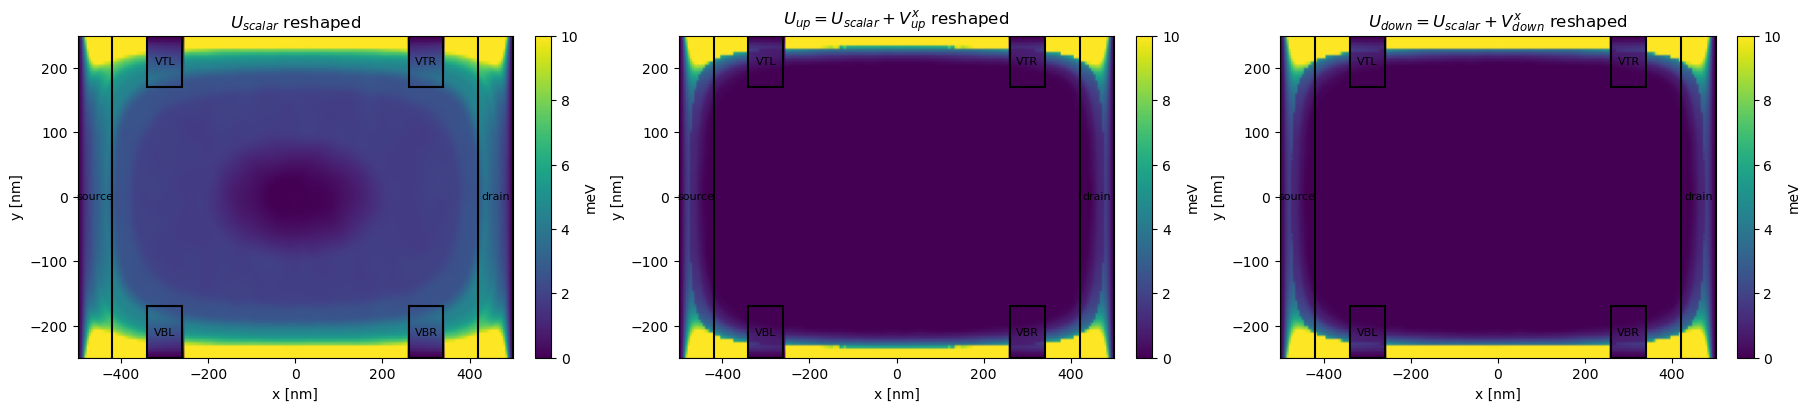

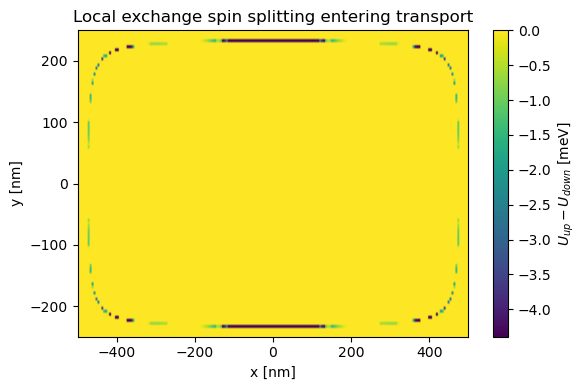

In [36]:
def lead_outline_rect(spec, x_nm, y_nm):
    xmin, xmax = float(x_nm.min()), float(x_nm.max())
    ymin, ymax = float(y_nm.min()), float(y_nm.max())
    a = max(abs(np.mean(np.diff(x_nm))), abs(np.mean(np.diff(y_nm))))

    if spec.side in ("left", "right"):
        coord_min, coord_max = ymin, ymax
        center = 0.5 * (coord_min + coord_max) if spec.center_nm is None else float(spec.center_nm)
        width = (coord_max - coord_min + a) if spec.width_nm is None else float(spec.width_nm)
        y0, y1 = center - 0.5 * width, center + 0.5 * width
        if spec.side == "left":
            x0, x1 = xmin, xmin + spec.depth_nm
        else:
            x0, x1 = xmax - spec.depth_nm, xmax
    else:
        coord_min, coord_max = xmin, xmax
        center = 0.5 * (coord_min + coord_max) if spec.center_nm is None else float(spec.center_nm)
        width = (coord_max - coord_min + a) if spec.width_nm is None else float(spec.width_nm)
        x0, x1 = center - 0.5 * width, center + 0.5 * width
        if spec.side == "bottom":
            y0, y1 = ymin, ymin + spec.depth_nm
        else:
            y0, y1 = ymax - spec.depth_nm, ymax
    return x0, y0, x1 - x0, y1 - y0

prep_scalar = prepare_frame(seq_scalar, index=FRAME_INDEX, cfg=cfg6)
prep_up = prepare_frame(seq_up, index=FRAME_INDEX, cfg=cfg6)
prep_down = prepare_frame(seq_down, index=FRAME_INDEX, cfg=cfg6)

print("frame index:", FRAME_INDEX)
print("B =", prep_scalar.B_T, "T")
print("t =", prep_scalar.t_meV, "meV")
print("alpha =", prep_scalar.alpha, "flux quanta/plaquette")
print("lB =", prep_scalar.lB_nm, "nm")
print("hbar omega_c =", prep_scalar.omega_c_meV, "meV")

extent = [seq.x_nm.min(), seq.x_nm.max(), seq.y_nm.min(), seq.y_nm.max()]

fig, axs = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
images = [
    (prep_scalar.U_for_transport_meV, r"$U_{scalar}$ reshaped"),
    (prep_up.U_for_transport_meV, r"$U_{up}=U_{scalar}+V^x_{up}$ reshaped"),
    (prep_down.U_for_transport_meV, r"$U_{down}=U_{scalar}+V^x_{down}$ reshaped"),
]

vmin = 0#min(np.nanpercentile(arr, 1) for arr, _ in images)
vmax = 10#max(np.nanpercentile(arr, 99) for arr, _ in images)

for ax, (arr, title) in zip(axs, images):
    im = ax.imshow(arr, origin="lower", extent=extent, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("x [nm]")
    ax.set_ylabel("y [nm]")
    for spec in cfg6.lead_specs:
        x0, y0, w, h = lead_outline_rect(spec, seq.x_nm, seq.y_nm)
        ax.add_patch(plt.Rectangle((x0, y0), w, h, fill=False, lw=1.5))
        ax.text(x0 + 0.5*w, y0 + 0.5*h, spec.name, ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="meV")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(prep_up.U_for_transport_meV - prep_down.U_for_transport_meV,
           origin="lower", extent=extent, aspect="auto")
plt.colorbar(label=r"$U_{up}-U_{down}$ [meV]")
plt.xlabel("x [nm]")
plt.ylabel("y [nm]")
plt.title("Local exchange spin splitting entering transport")
plt.tight_layout()
plt.show()


## 4. Spin-resolved transport helper functions

Each branch is built as a scalar Kwant system using either `U_up` or `U_down`.
Zeeman splitting is included as an energy shift:

```text
E_transport,up   = mu - (+0.5 g*hwc)
E_transport,down = mu - (-0.5 g*hwc)
```

This matches the spin convention used in the spin/exchange Thomas--Fermi notebook.


number of leads: 6


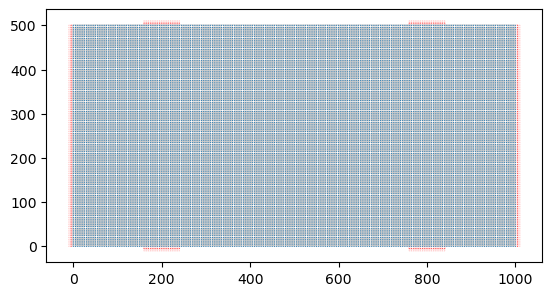

In [37]:
import kwant

HBAR_OMEGA_C_FREE_MEV_PER_T = 0.115767638  # hbar*e/m_e in meV/T


def _metadata_params(frame):
    """Return the params dictionary from a sequence frame, robustly."""
    md = getattr(frame, "metadata", None)
    if md is None and isinstance(frame, dict):
        md = frame.get("metadata", frame)
    if md is None:
        return {}
    return md.get("params", md) if isinstance(md, dict) else {}


def _metadata_summary(frame):
    md = getattr(frame, "metadata", None)
    if md is None and isinstance(frame, dict):
        md = frame.get("metadata", frame)
    if md is None or not isinstance(md, dict):
        return {}
    return md.get("summary", {})


def branch_zeeman_shift_meV(frame, prep, branch, default_g_spin=-0.44, default_m_eff=0.067):
    """Return ±E_Z/2 in meV for the spin branch.

    The spin/exchange TF notebook used
        E_Z = g_spin * hbar_omega_c.
    Here `branch='up'` gets +E_Z/2 and `branch='down'` gets -E_Z/2.
    """
    params = _metadata_params(frame)
    g_spin = float(params.get("g_spin", default_g_spin))
    m_eff = float(params.get("m_eff", default_m_eff))

    # Prefer the value produced by prepare_frame if available; otherwise use B and m_eff.
    hwc = getattr(prep, "omega_c_meV", None)
    if hwc is None:
        B_T = float(getattr(prep, "B_T", params.get("B", params.get("B_T", 0.0))))
        hwc = HBAR_OMEGA_C_FREE_MEV_PER_T * B_T / m_eff

    E_Z = g_spin * float(hwc)
    if branch == "up":
        return +0.5 * E_Z
    if branch == "down":
        return -0.5 * E_Z
    raise ValueError("branch must be 'up' or 'down'")


def transmission_matrix_from_smatrix(smat, n_leads):
    T = np.zeros((n_leads, n_leads), dtype=float)
    for i in range(n_leads):
        for j in range(n_leads):
            if i != j:
                T[i, j] = smat.transmission(i, j)
    return T


def run_one_scalar_branch(seq_branch, index, cfg, energy_meV):
    """Run one scalar Kwant frame at a specified scattering energy."""
    prep = prepare_frame(seq_branch, index=index, cfg=cfg)
    builder = build_kwant_builder(prep, cfg)
    fsyst, phase_params = finalize_with_magnetic_field(
        builder,
        prep.B_T,
        len(cfg.lead_specs),
        cfg.lead_B_mode,
    )
    smat = kwant.smatrix(fsyst, energy=float(energy_meV), params=phase_params)
    T = transmission_matrix_from_smatrix(smat, len(cfg.lead_specs))
    return prep, smat, T


def run_one_spin_resolved_frame(seq_up, seq_down, index, cfg, energy_selector):
    """Run up/down branches and return total transmission.

    Returns
    -------
    prep_ref : prepared scalar frame, useful for B/grid diagnostics
    out : dict containing branch energies, branch transmissions and smatrices
    T_total : T_up + T_down
    """
    frame_up = seq_up.frame(index)
    prep_ref = prepare_frame(seq_up, index=index, cfg=cfg)
    mu = float(energy_selector(frame_up))

    z_up = branch_zeeman_shift_meV(frame_up, prep_ref, "up", default_m_eff=cfg.m_eff)
    z_down = branch_zeeman_shift_meV(frame_up, prep_ref, "down", default_m_eff=cfg.m_eff)
    E_up = mu - z_up
    E_down = mu - z_down

    prep_up, smat_up, T_up = run_one_scalar_branch(seq_up, index, cfg, E_up)
    prep_down, smat_down, T_down = run_one_scalar_branch(seq_down, index, cfg, E_down)

    out = {
        "mu_meV": mu,
        "E_up_meV": E_up,
        "E_down_meV": E_down,
        "zeeman_shift_up_meV": z_up,
        "zeeman_shift_down_meV": z_down,
        "prep_up": prep_up,
        "prep_down": prep_down,
        "smat_up": smat_up,
        "smat_down": smat_down,
        "T_up": T_up,
        "T_down": T_down,
    }
    return prep_ref, out, T_up + T_down


# Build and plot one branch just to inspect the geometry.
builder6_up = build_kwant_builder(prep_up, cfg6)
fsyst6_up, phase_params6_up = finalize_with_magnetic_field(
    builder6_up,
    prep_up.B_T,
    len(cfg6.lead_specs),
    cfg6.lead_B_mode,
)

print("number of leads:", len(fsyst6_up.leads))
kwant.plot(fsyst6_up);


## 5. Run one spin-resolved six-terminal frame

By default the code reads the Hartree chemical potential `mu` from the spin/exchange
sweep metadata and uses it as the common Fermi energy before applying the branch
Zeeman energy shifts.


In [38]:
selector = hartree_energy_selector(
    key_candidates=[
        "summary.mu", "params.mu", "mu", "chemical_potential",
        "chemical_potential_meV", "fermi_energy", "fermi_energy_meV",
    ],
    unit="meV",
)

prep6, spin_out6, T6 = run_one_spin_resolved_frame(
    seq_up,
    seq_down,
    index=FRAME_INDEX,
    cfg=cfg6,
    energy_selector=selector,
)

np.set_printoptions(precision=4, suppress=True)
print("B =", prep6.B_T, "T")
print("mu =", spin_out6["mu_meV"], "meV")
print("E_up =", spin_out6["E_up_meV"], "meV")
print("E_down =", spin_out6["E_down_meV"], "meV")
print("Zeeman shifts up/down =", spin_out6["zeeman_shift_up_meV"], spin_out6["zeeman_shift_down_meV"], "meV")
print("T_total[i, j] = transmission from lead j into lead i, summed over spin branches")
print(T6)

G_2terminal = T6[1, 0]
Rxx_left = four_terminal_resistance_h_over_e2(T6, source=0, drain=1, vplus=3, vminus=5)  # top-left minus top-right
Rxx_bottom = four_terminal_resistance_h_over_e2(T6, source=0, drain=1, vplus=2, vminus=4)  # bottom-left minus bottom-right
Rxy_left = four_terminal_resistance_h_over_e2(T6, source=0, drain=1, vplus=3, vminus=2)  # top-left minus bottom-left
Rxy_right = four_terminal_resistance_h_over_e2(T6, source=0, drain=1, vplus=5, vminus=4)  # top-right minus bottom-right

print("G_10 total [e^2/h] =", G_2terminal)
print("G_10 up/down [e^2/h] =", spin_out6["T_up"][1, 0], spin_out6["T_down"][1, 0])
print("Rxx_left  [h/e^2] =", Rxx_left)
print("Rxx_bottom[h/e^2] =", Rxx_bottom)
print("Rxy_left  [h/e^2] =", Rxy_left)
print("Rxy_right [h/e^2] =", Rxy_right)


B = 1.491638795986622 T
mu = 6.995246740156191 meV
E_up = 6.673076025335646 meV
E_down = 7.317417454976737 meV
Zeeman shifts up/down = 0.32217071482054604 -0.32217071482054604 meV
T_total[i, j] = transmission from lead j into lead i, summed over spin branches
[[0.     1.4079 4.8645 0.1158 3.9197 0.2183]
 [1.4443 0.     0.1981 3.89   0.1227 4.8678]
 [0.1235 3.9113 0.     0.2766 1.0473 0.1498]
 [4.8724 0.2044 0.2798 0.     0.1508 0.0301]
 [0.1817 4.8927 0.024  0.1471 0.     0.2629]
 [3.9044 0.1065 0.1421 1.1081 0.2678 0.    ]]
G_10 total [e^2/h] = 1.444254613148905
G_10 up/down [e^2/h] = 0.8680108240449038 0.5762437891040011
Rxx_left  [h/e^2] = 2.1090747905988527e-05
Rxx_bottom[h/e^2] = 0.0011419386908963786
Rxy_left  [h/e^2] = 0.08415289106524466
Rxy_right [h/e^2] = 0.08527373900823505


## 6. Run a B sweep

The total transport is obtained by summing the two spin transmission matrices at each
magnetic field. Set `B_STRIDE = 1` for the full sweep.


In [39]:
B_STRIDE = 2
indices = range(0, len(seq_up.B_values_T), B_STRIDE)

results6 = []

for i in indices:
    prep_i, spin_out_i, T_i = run_one_spin_resolved_frame(
        seq_up,
        seq_down,
        index=i,
        cfg=cfg6,
        energy_selector=selector,
    )
    results6.append({
        "index": i,
        "B_T": prep_i.B_T,
        "mu_meV": spin_out_i["mu_meV"],
        "E_up_meV": spin_out_i["E_up_meV"],
        "E_down_meV": spin_out_i["E_down_meV"],
        "zeeman_shift_up_meV": spin_out_i["zeeman_shift_up_meV"],
        "zeeman_shift_down_meV": spin_out_i["zeeman_shift_down_meV"],
        "T": T_i,
        "T_up": spin_out_i["T_up"],
        "T_down": spin_out_i["T_down"],
        "G10_e2h": T_i[1, 0],
        "G10_up_e2h": spin_out_i["T_up"][1, 0],
        "G10_down_e2h": spin_out_i["T_down"][1, 0],
        "Rxx_left_h_e2": four_terminal_resistance_h_over_e2(T_i, source=0, drain=1, vplus=3, vminus=5),
        "Rxx_bottom_h_e2": four_terminal_resistance_h_over_e2(T_i, source=0, drain=1, vplus=2, vminus=4),
        "Rxy_left_h_e2": four_terminal_resistance_h_over_e2(T_i, source=0, drain=1, vplus=3, vminus=2),
        "Rxy_right_h_e2": four_terminal_resistance_h_over_e2(T_i, source=0, drain=1, vplus=5, vminus=4),
    })
    print(f"done index={i}, B={prep_i.B_T:.4g} T")

B = np.array([r["B_T"] for r in results6])
mu = np.array([r["mu_meV"] for r in results6])
E_up = np.array([r["E_up_meV"] for r in results6])
E_down = np.array([r["E_down_meV"] for r in results6])
G10 = np.array([r["G10_e2h"] for r in results6])
G10_up = np.array([r["G10_up_e2h"] for r in results6])
G10_down = np.array([r["G10_down_e2h"] for r in results6])
Rxx_left = np.array([r["Rxx_left_h_e2"] for r in results6])
Rxx_bottom = np.array([r["Rxx_bottom_h_e2"] for r in results6])
Rxy_left = np.array([r["Rxy_left_h_e2"] for r in results6])
Rxy_right = np.array([r["Rxy_right_h_e2"] for r in results6])


done index=0, B=1 T
done index=2, B=1 T
done index=4, B=1.01 T
done index=6, B=1.03 T
done index=8, B=1.05 T
done index=10, B=1.07 T
done index=12, B=1.09 T
done index=14, B=1.11 T
done index=16, B=1.13 T
done index=18, B=1.151 T
done index=20, B=1.171 T
done index=22, B=1.191 T
done index=24, B=1.211 T
done index=26, B=1.231 T
done index=28, B=1.251 T
done index=30, B=1.271 T
done index=32, B=1.291 T
done index=34, B=1.311 T
done index=36, B=1.331 T
done index=38, B=1.351 T
done index=40, B=1.371 T
done index=42, B=1.391 T
done index=44, B=1.411 T
done index=46, B=1.431 T
done index=48, B=1.452 T
done index=50, B=1.472 T
done index=52, B=1.492 T


## 7. Plot six-terminal observables

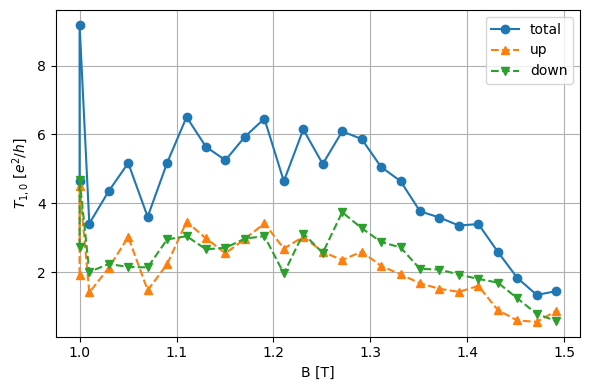

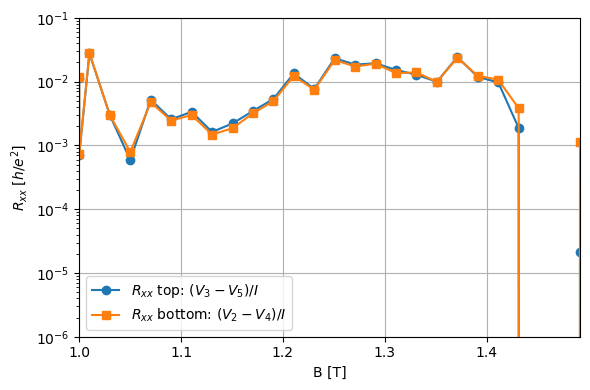

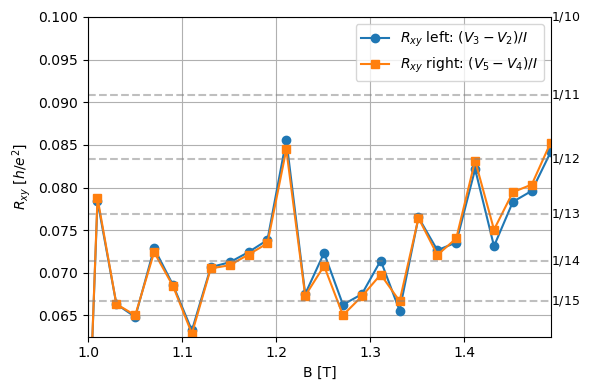

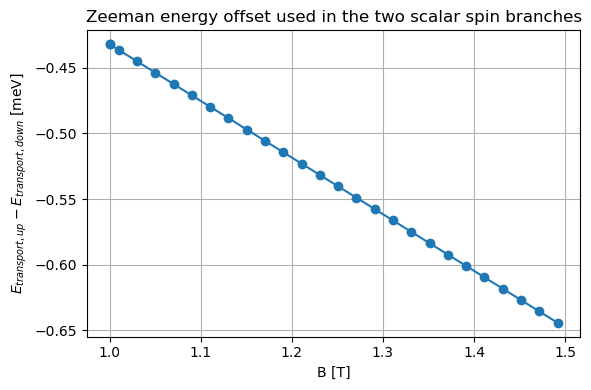

In [42]:
plt.figure(figsize=(6, 4))
plt.plot(B, G10, marker="o", label="total")
plt.plot(B, G10_up, marker="^", ls="--", label="up")
plt.plot(B, G10_down, marker="v", ls="--", label="down")
plt.xlabel("B [T]")
plt.ylabel(r"$T_{1,0}$ [$e^2/h$]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(B, Rxx_left, marker="o", label=r"$R_{xx}$ top: $(V_3 - V_5)/I$")
plt.plot(B, Rxx_bottom, marker="s", label=r"$R_{xx}$ bottom: $(V_2 - V_4)/I$")
plt.xlabel("B [T]")
plt.ylabel(r"$R_{xx}$ [$h/e^2$]")
plt.yscale('log')
plt.ylim(1e-6, 1e-1)
plt.xlim(np.nanmin(B), np.nanmax(B))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(B, Rxy_left, marker="o", label=r"$R_{xy}$ left: $(V_3 - V_2)/I$")
plt.plot(B, Rxy_right, marker="s", label=r"$R_{xy}$ right: $(V_5 - V_4)/I$")
plt.xlabel("B [T]")
plt.ylabel(r"$R_{xy}$ [$h/e^2$]")
plt.xlim(np.nanmin(B), np.nanmax(B))
plt.ylim(1./16.,1./10.)
# Horizontal lines at y = 1/n
for n in range(10, 16):
    plt.axhline(1/n, color='gray', linestyle='--', alpha=0.5)
    plt.text(np.nanmax(B), 1/n, rf"$1/{n}$", va='center', fontsize=9)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(B, E_up - E_down, marker="o")
plt.xlabel("B [T]")
plt.ylabel(r"$E_{transport,up}-E_{transport,down}$ [meV]")
plt.title("Zeeman energy offset used in the two scalar spin branches")
plt.grid(True)
plt.tight_layout()
plt.show()


## 8. Save numerical results

In [41]:
outfile = "six_terminal_transport_results_spin_exchange.npz"
np.savez(
    outfile,
    B=B,
    mu=mu,
    E_up=E_up,
    E_down=E_down,
    G10=G10,
    G10_up=G10_up,
    G10_down=G10_down,
    Rxx_left=Rxx_left,
    Rxx_bottom=Rxx_bottom,
    Rxy_left=Rxy_left,
    Rxy_right=Rxy_right,
    T_stack=np.stack([r["T"] for r in results6], axis=0),
    T_up_stack=np.stack([r["T_up"] for r in results6], axis=0),
    T_down_stack=np.stack([r["T_down"] for r in results6], axis=0),
    indices=np.array([r["index"] for r in results6]),
)
print("saved", outfile)


saved six_terminal_transport_results_spin_exchange.npz
